In [4]:
import os, zipfile, glob


zip_candidates = glob.glob("/content/gno_run_artifacts.zip")
assert len(zip_candidates) >= 1, "No gno_run_artifacts zip found in /content"

zip_path = zip_candidates[0]
print("Using zip:", zip_path)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("/content")


matches = glob.glob("/content/**/gno_artifacts.pt", recursive=True)
assert len(matches) == 1, f"Expected one gno_artifacts.pt, found: {matches}"

ARTIFACT_PATH = matches[0]
print("Found artifact at:", ARTIFACT_PATH)


Using zip: /content/gno_run_artifacts.zip
Found artifact at: /content/content/gno_run_artifacts/gno_artifacts.pt


In [5]:
!pip install torch-geometric -q

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

artifact = torch.load(ARTIFACT_PATH, map_location="cpu", weights_only=False)
print("Loaded keys:", sorted(artifact.keys()))



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 40.8 MB/s eta 0:00:00
Loaded keys: ['df_scenarios', 'df_test', 'df_val', 'edge_attr', 'edge_index', 'feature_columns', 'model_config', 'model_state_dict', 'node_ids', 'node_index_map', 'norm_stats', 'original_target_col', 'pos', 'scenario_data', 'target_col', 'test_data', 'test_times', 'train_times', 'val_data', 'val_times']


In [6]:
!pip install torch-geometric -q

import torch.nn as nn
import torch.nn.functional as F
from nn_conv import NNConv_old

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

class DenseNet(nn.Module):
    def __init__(self, layers, activation):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
        self.activation = activation()
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        return self.layers[-1](x)

class KernelNN(nn.Module):
    def __init__(self, in_width, edge_feat_dim, width=96, ker_width=256, depth=5, out_width=1):
        super().__init__()
        self.depth = depth
        self.fc1 = nn.Linear(in_width, width)
        kernel = DenseNet([edge_feat_dim, ker_width, ker_width, width*width], nn.ReLU)
        self.conv1 = NNConv_old(width, width, kernel, aggr="mean")
        self.fc2 = nn.Linear(width, out_width)
    def forward(self, data):
        x = self.fc1(data.x)
        for _ in range(self.depth):
            x = F.relu(self.conv1(x, data.edge_index, data.edge_attr))
        return self.fc2(x).squeeze(-1)

cfg = artifact["model_config"]
model = KernelNN(
    in_width=cfg["in_width"],
    edge_feat_dim=cfg["edge_feat_dim"],
    width=cfg["hidden_width"],
    ker_width=cfg["kernel_width"],
    depth=cfg["depth"],
    out_width=cfg["out_width"],
).to(device)

model.load_state_dict(artifact["model_state_dict"])
model.eval()
print("Model loaded.")


device: cuda
Model loaded.


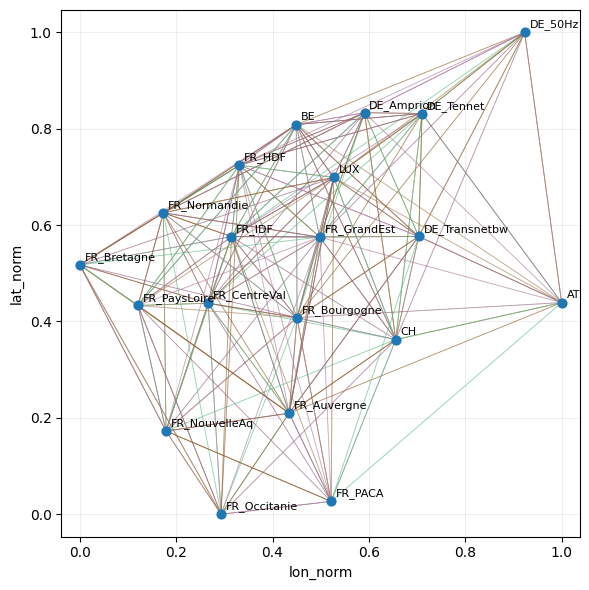

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
#build graph and visualize from artifact
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


pos = artifact["pos"]
edge_index = artifact["edge_index"]
node_index_map = artifact["node_index_map"]
node_ids = list(node_index_map.keys())

pos_np = pos.cpu().numpy()
node_df = pd.DataFrame(index=node_ids, data={"lat_norm": pos_np[:, 0], "lon_norm": pos_np[:, 1]})

def plot_graph_layout(node_df, pos, edge_index, title="Graph layout (normalized lat/lon)"):

    pos_np = pos.cpu().numpy()  ]
    lat = pos_np[:, 0]
    lon = pos_np[:, 1]

    row, col = edge_index

    plt.figure(figsize=(6, 6))

    for r, c in zip(row.tolist(), col.tolist()):
        plt.plot(
            [lon[r], lon[c]],
            [lat[r], lat[c]],
            linewidth=0.6,
            alpha=0.4,
        )

    plt.scatter(lon, lat, s=40, zorder=3)

    for i, node_id in enumerate(node_df.index):
        plt.text(
            lon[i] + 0.01,
            lat[i] + 0.01,
            str(node_id),
            fontsize=8,
        )

    plt.xlabel("lon_norm")
    plt.ylabel("lat_norm")
    #plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()

plot_graph_layout(node_df, pos, edge_index)

GRAPH_PDF = "/content/graph_layout.pdf"
plt.savefig(GRAPH_PDF, bbox_inches="tight")
plt.show()

files.download(GRAPH_PDF)


In [8]:
#build scenario_data (4 weeks) from artifact

import pandas as pd
import torch
import numpy as np
from torch_geometric.data import Data


edge_index = artifact["edge_index"]
edge_attr  = artifact["edge_attr"]
node_index_map = artifact["node_index_map"]

FEATURE_COLUMNS = artifact["feature_columns"]
TARGET_COL = artifact["target_col"]


df_scen_n = artifact["df_scenarios"].copy()

TIME_COL = "datetime"


df_scen_n["node_idx"] = df_scen_n["node_id"].map(node_index_map)

needs_lat = "lat_norm" in FEATURE_COLUMNS and "lat_norm" not in df_scen_n.columns
needs_lon = "lon_norm" in FEATURE_COLUMNS and "lon_norm" not in df_scen_n.columns

if needs_lat or needs_lon:
    pos_np = artifact["pos"].detach().cpu().numpy()
    lat_by_idx = pos_np[:, 0]
    lon_by_idx = pos_np[:, 1]

    if needs_lat:
        df_scen_n["lat_norm"] = df_scen_n["node_idx"].map(
            lambda i: float(lat_by_idx[int(i)]) if pd.notna(i) else np.nan
        )

    if needs_lon:
        df_scen_n["lon_norm"] = df_scen_n["node_idx"].map(
            lambda i: float(lon_by_idx[int(i)]) if pd.notna(i) else np.nan
        )

    assert df_scen_n["lat_norm"].notna().all()
    assert df_scen_n["lon_norm"].notna().all()


missing_cols = [c for c in FEATURE_COLUMNS if c not in df_scen_n.columns]
assert not missing_cols, f"Missing feature columns: {missing_cols}"

def build_dataset_from_panel_local(
    df_split, node_index_map, edge_index, edge_attr,
    feature_cols, target_col, time_col="datetime"
):
    data_list = []
    unique_times = pd.to_datetime(df_split[time_col]).sort_values().unique()
    num_nodes = len(node_index_map)

    for t in unique_times:
        df_t = df_split[pd.to_datetime(df_split[time_col]) == t].sort_values("node_idx")
        if len(df_t) != num_nodes:
            continue

        x = torch.tensor(df_t[feature_cols].values, dtype=torch.float32)
        y = torch.tensor(df_t[target_col].values, dtype=torch.float32)

        data = Data(x=x, y=y, edge_index=edge_index, edge_attr=edge_attr)
        data_list.append(data)

    return data_list, unique_times

#build scenario dataset
scenario_data, scenario_times = build_dataset_from_panel_local(
    df_scen_n,
    node_index_map,
    edge_index,
    edge_attr,
    FEATURE_COLUMNS,
    TARGET_COL,
    time_col=TIME_COL,
)

print("Scenario graphs:", len(scenario_data))


Scenario graphs: 672


/tmp/ipykernel_28311/1262701096.py:18: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)


Scenario timesteps: 672 | Num nodes: 20


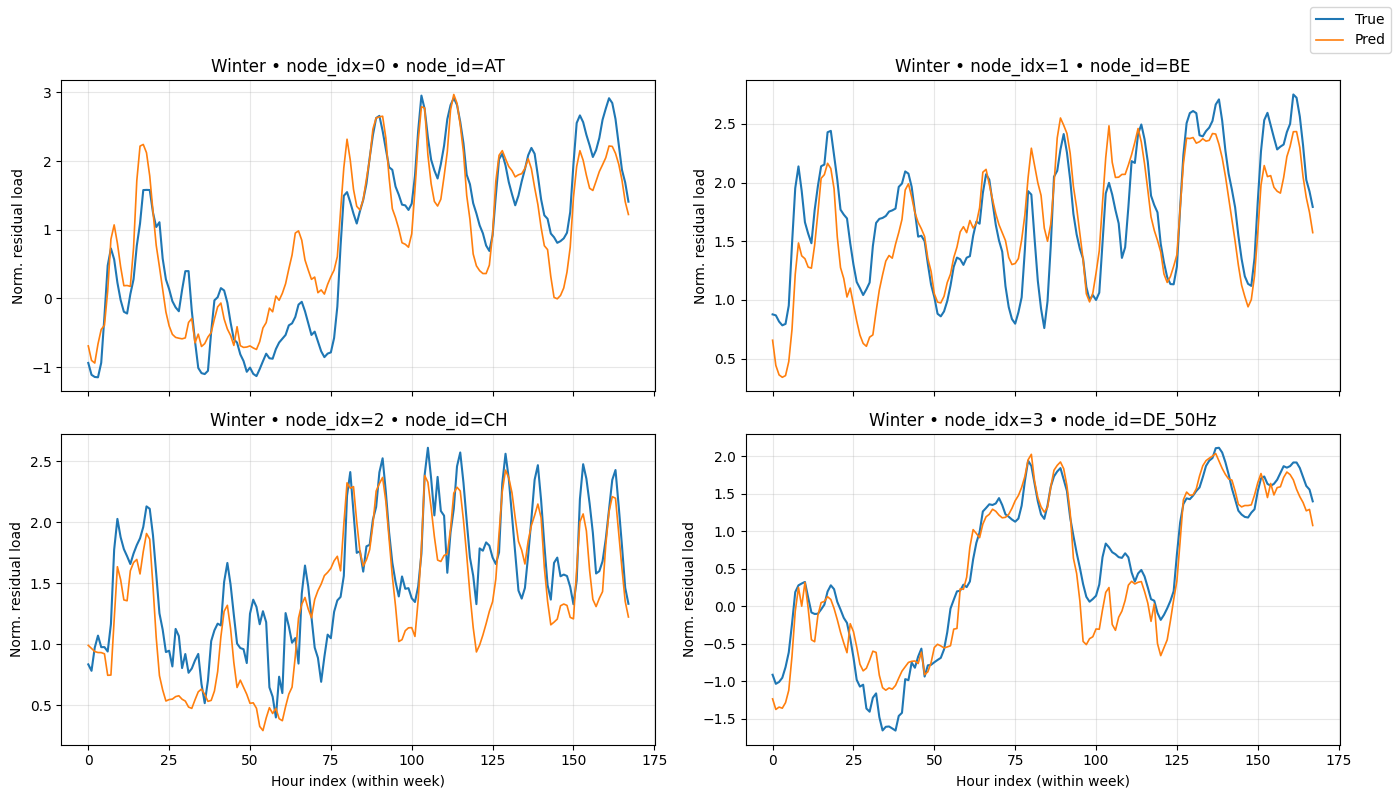

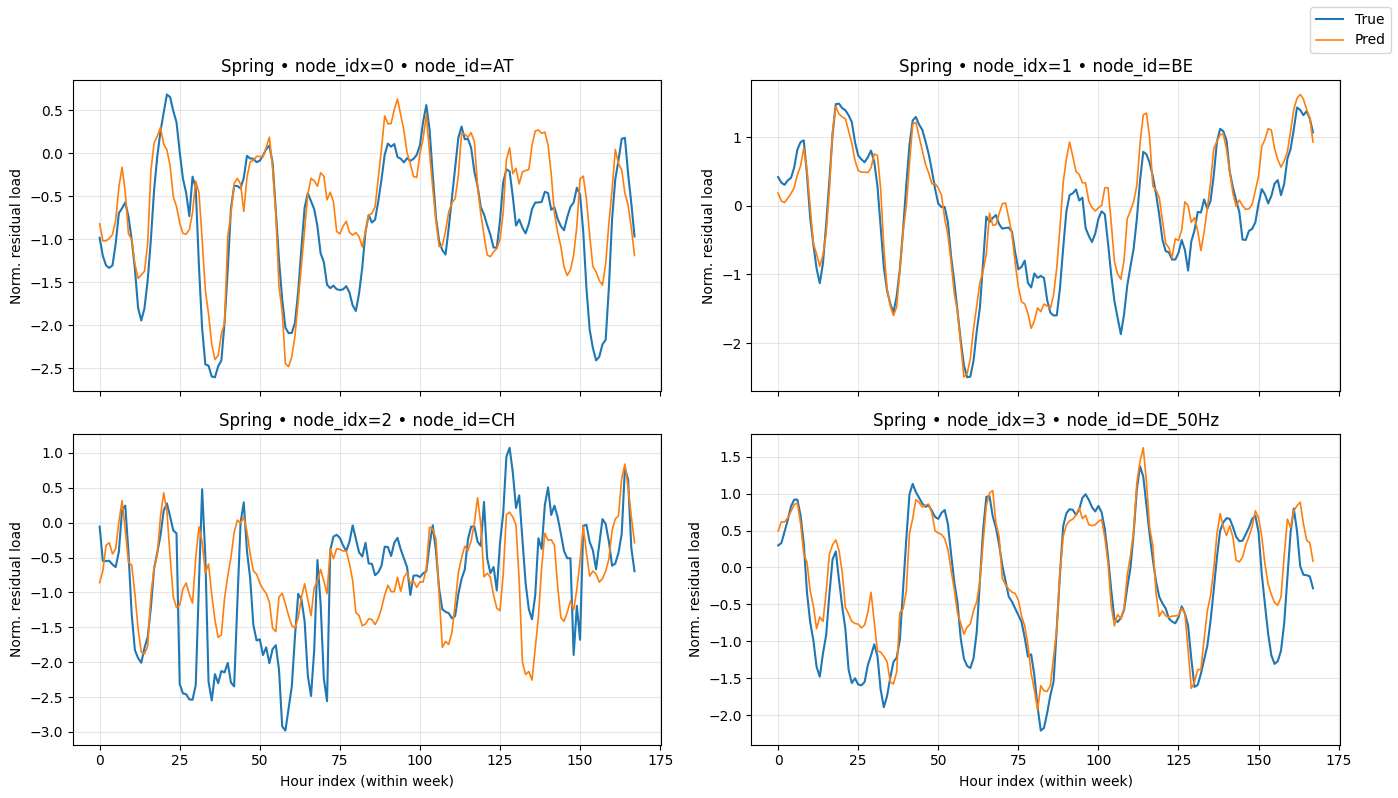

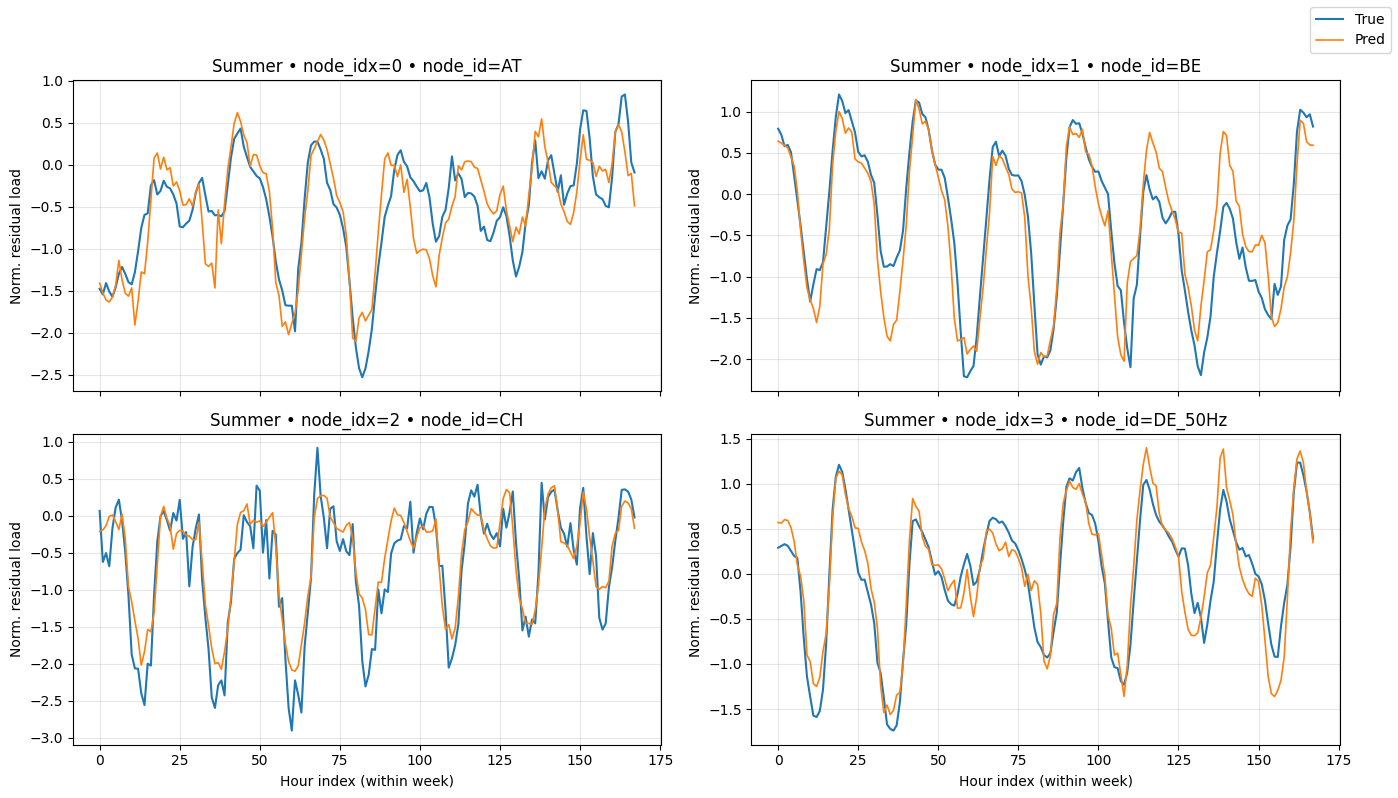

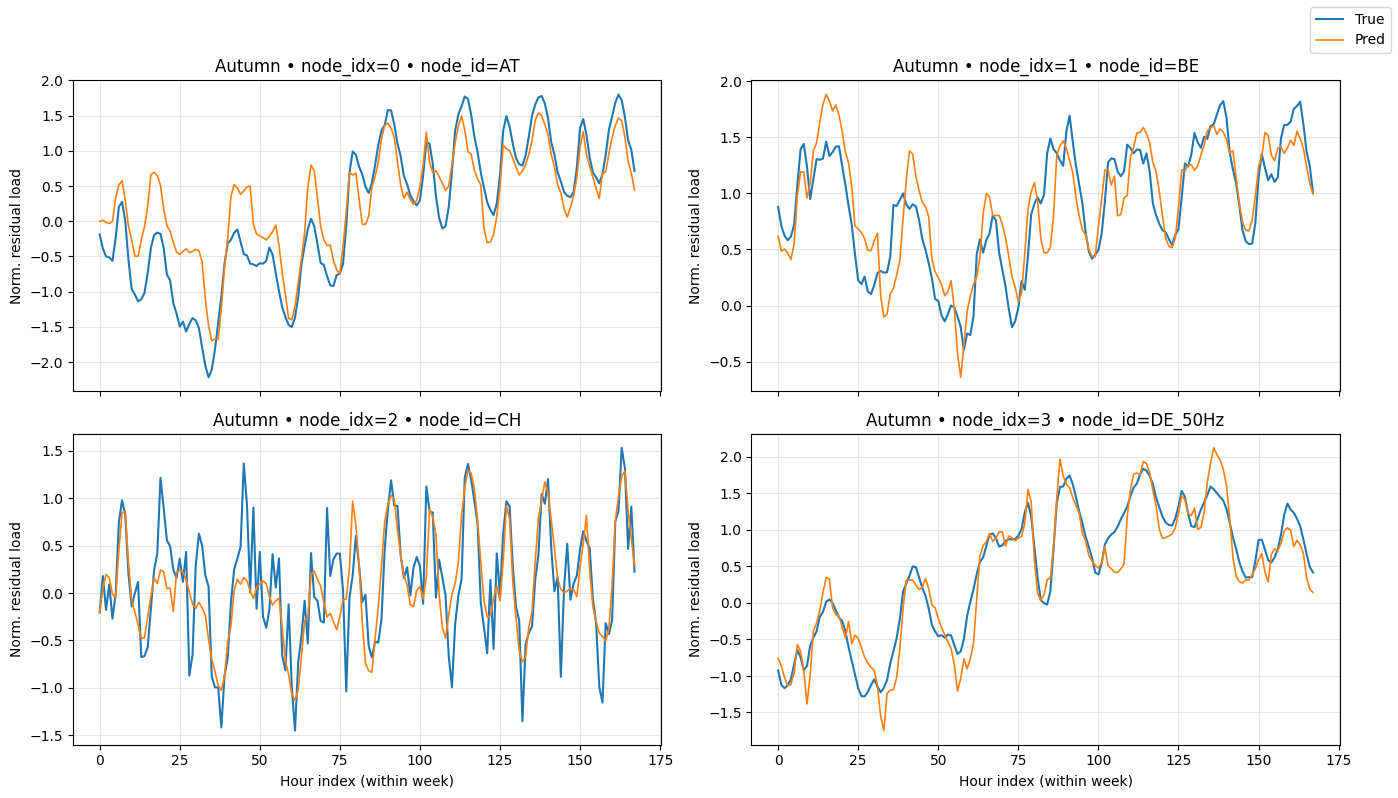

Saved PDFs: ['/content/pred_vs_true_winter.pdf', '/content/pred_vs_true_spring.pdf', '/content/pred_vs_true_summer.pdf', '/content/pred_vs_true_autumn.pdf']
Zipped to: /content/pred_vs_true_plots.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
#batch inference + plot true vs pred for 4 nodes, 4 hidden weeks
#save 4 PDFs + zip + download

import numpy as np
import torch
import matplotlib.pyplot as plt
from torch_geometric.data import DataLoader
from google.colab import files
import os

def collect_predictions_2d_fast(model, dataset, batch_size=16):
    """
    Returns:
      y_pred_2d: (T, N)
      y_true_2d: (T, N)
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    preds_chunks, trues_chunks = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            pred = model(batch)
            true = batch.y
            preds_chunks.append(pred.detach().cpu())
            trues_chunks.append(true.detach().cpu())

    y_pred = torch.cat(preds_chunks, dim=0).numpy()
    y_true = torch.cat(trues_chunks, dim=0).numpy()

    T = len(dataset)
    N = dataset[0].y.numel()
    return y_pred.reshape(T, N), y_true.reshape(T, N)


y_pred_scen_2d, y_true_scen_2d = collect_predictions_2d_fast(model, scenario_data, batch_size=16)

T_scen, num_nodes = y_true_scen_2d.shape
print("Scenario timesteps:", T_scen, "| Num nodes:", num_nodes)

one_week = 7 * 24
assert T_scen == 4 * one_week, f"Expected 672 timesteps, got {T_scen}"


nodes_to_plot = [0, 1, 2, 3]
week_names = ["Winter", "Spring", "Summer", "Autumn"]

saved_pdfs = []

for week_idx in range(4):
    start_idx = week_idx * one_week
    end_idx   = (week_idx + 1) * one_week

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.flatten()

    for ax, node_idx in zip(axes, nodes_to_plot):
        true_node = y_true_scen_2d[start_idx:end_idx, node_idx]
        pred_node = y_pred_scen_2d[start_idx:end_idx, node_idx]

        ax.plot(true_node, label="True", linewidth=1.5)
        ax.plot(pred_node, label="Pred", linewidth=1.2)
        ax.set_title(f"{week_names[week_idx]} • node_idx={node_idx} • node_id={node_ids[node_idx]}")
        ax.set_ylabel("Norm. residual load")
        ax.grid(True, alpha=0.3)

    axes[-2].set_xlabel("Hour index (within week)")
    axes[-1].set_xlabel("Hour index (within week)")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    # fig.suptitle(f"Residual load • 4 nodes • {week_names[week_idx]} week", fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.98, 0.95])

    pdf_path = f"/content/pred_vs_true_{week_names[week_idx].lower()}.pdf"
    plt.savefig(pdf_path, bbox_inches="tight")
    saved_pdfs.append(pdf_path)

    plt.show()
    plt.close(fig)

print("Saved PDFs:", saved_pdfs)


ZIP_NAME = "/content/pred_vs_true_plots.zip"
if os.path.exists(ZIP_NAME):
    os.remove(ZIP_NAME)

!zip -j pred_vs_true_plots.zip /content/pred_vs_true_*.pdf > /dev/null

print("Zipped to:", ZIP_NAME)
files.download(ZIP_NAME)


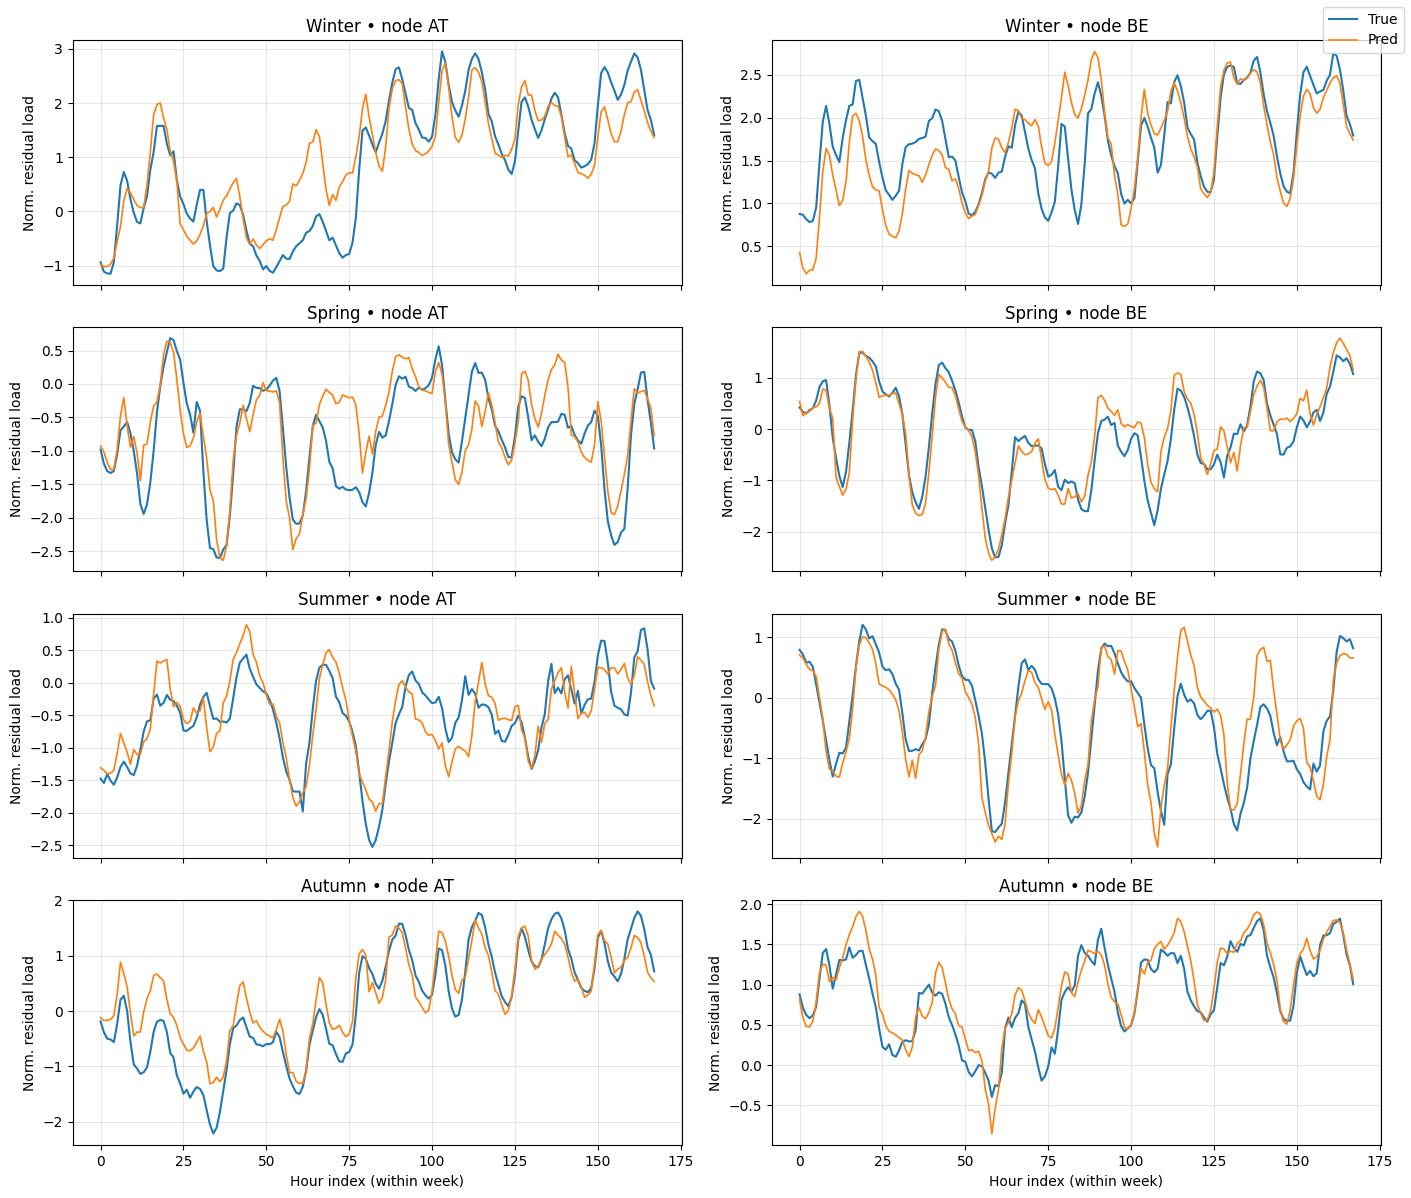

Saved PDF: /content/pred_vs_true_all_seasons_node0_node1.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#figure: 4 seasons, only node 0 & 3

import matplotlib.pyplot as plt
import os
from google.colab import files

one_week = 7 * 24
nodes_to_plot = [0, 1]
season_names = ["Winter", "Spring", "Summer", "Autumn"]

saved_pdfs = []

fig, axes = plt.subplots(4, 2, figsize=(14, 12), sharex=True)


for season_idx, season in enumerate(season_names):
    start = season_idx * one_week
    end   = (season_idx + 1) * one_week

    for col, node_idx in enumerate(nodes_to_plot):
        ax = axes[season_idx, col]

        ax.plot(y_true_scen_2d[start:end, node_idx], label="True", linewidth=1.5)
        ax.plot(y_pred_scen_2d[start:end, node_idx], label="Pred", linewidth=1.2)

        ax.set_title(f"{season} • node {node_ids[node_idx]}")
        ax.set_ylabel("Norm. residual load")
        ax.grid(True, alpha=0.3)

        if season_idx == 3:
            ax.set_xlabel("Hour index (within week)")


handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.tight_layout()

pdf_path = "/content/pred_vs_true_all_seasons_node0_node1.pdf"
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Saved PDF:", pdf_path)

files.download(pdf_path)


In [ ]:
#Eval: RMSE on 4 unseen weeks (per season, per node, node-season matrix)

import numpy as np
import pandas as pd


T, N = y_true_scen_2d.shape
one_week = 7 * 24
assert T == 4 * one_week, f"Expected 672 timesteps, got {T}"

season_names = ["Winter", "Spring", "Summer", "Autumn"]

def rmse(a, b, axis=None):
    return np.sqrt(np.mean((a - b) ** 2, axis=axis))

rmse_season_node = np.zeros((4, N), dtype=float)

for s in range(4):
    start, end = s * one_week, (s + 1) * one_week
    rmse_season_node[s, :] = rmse(y_true_scen_2d[start:end, :], y_pred_scen_2d[start:end, :], axis=0)

rmse_per_season = rmse_season_node.mean(axis=1)


rmse_per_node = rmse_season_node.mean(axis=0)


rmse_overall = rmse(y_true_scen_2d, y_pred_scen_2d)


df_rmse_season = pd.DataFrame({
    "Season": season_names,
    "RMSE_avg_over_nodes": rmse_per_season
})

df_rmse_node = pd.DataFrame({
    "node_id": node_ids,
    "RMSE_avg_over_seasons": rmse_per_node
}).sort_values("RMSE_avg_over_seasons")

df_rmse_matrix = pd.DataFrame(rmse_season_node, index=season_names, columns=node_ids)

print("Overall RMSE (all seasons/nodes/timesteps)")
print(rmse_overall)

print("\nMSE per season (avg over nodes)")
print(df_rmse_season.to_string(index=False))

print("\nRMSE per node (avg over seasons), sorted")
print(df_rmse_node.to_string(index=False))

print("\nRMSE matrix: seasons x node_id")
print(df_rmse_matrix.round(4).to_string())


=== Overall RMSE (all seasons/nodes/timesteps) ===
0.35029557

=== RMSE per season (avg over nodes) ===
Season  RMSE_avg_over_nodes
Winter             0.365331
Spring             0.342810
Summer             0.318081
Autumn             0.316276

=== RMSE per node (avg over seasons), sorted ===
      node_id  RMSE_avg_over_seasons
       FR_IDF               0.169574
 FR_Normandie               0.272679
 FR_PaysLoire               0.275939
DE_Transnetbw               0.291338
  FR_Auvergne               0.291943
      DE_50Hz               0.292527
 FR_Occitanie               0.298303
      FR_PACA               0.301817
       FR_HDF               0.309262
  FR_Bretagne               0.310556
   DE_Amprion               0.316907
 FR_CentreVal               0.346697
          LUX               0.352951
           BE               0.359951
    DE_Tennet               0.373625
  FR_GrandEst               0.374066
FR_NouvelleAq               0.400957
 FR_Bourgogne               0.403067
   

In [ ]:
# dispersion across nodes
rmse_node_mean = float(np.mean(rmse_per_node))
rmse_node_std  = float(np.std(rmse_per_node))

print("Mean RMSE across nodes:", rmse_node_mean)
print("Std. RMSE across nodes:", rmse_node_std)


Mean RMSE across nodes: 0.33562451545149086
Std. RMSE across nodes: 0.07159557209109046


In [ ]:
#Latex-form table

import os


overall = float(rmse_overall)
df_tab = df_rmse_season.copy()


season_order = ["Winter", "Spring", "Summer", "Autumn"]
df_tab["Season"] = pd.Categorical(df_tab["Season"], categories=season_order, ordered=True)
df_tab = df_tab.sort_values("Season")

lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{l r}")
lines.append(r"\toprule")
lines.append(r"Season & RMSE \\")
lines.append(r"\midrule")
lines.append(rf"Overall & {overall:.4f} \\")
lines.append(r"\midrule")
for _, row in df_tab.iterrows():
    lines.append(rf"{row['Season']} & {float(row['RMSE_avg_over_nodes']):.4f} \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{RMSE on the four held-out seasonal weeks (average over nodes), along with overall RMSE across all seasons, nodes, and timesteps.}")
lines.append(r"\label{tab:rmse_season_overall}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)


out_path = "/content/rmse_season_overall.tex"
with open(out_path, "w") as f:
    f.write(latex_table)

print("\nSaved to:", out_path)


\begin{table}[t]
\centering
\begin{tabular}{l r}
\toprule
Season & RMSE \\
\midrule
Overall & 0.3503 \\
\midrule
Winter & 0.3653 \\
Spring & 0.3428 \\
Summer & 0.3181 \\
Autumn & 0.3163 \\
\bottomrule
\end{tabular}
\caption{RMSE on the four held-out seasonal weeks (average over nodes), along with overall RMSE across all seasons, nodes, and timesteps.}
\label{tab:rmse_season_overall}
\end{table}

Saved to: /content/rmse_season_overall.tex


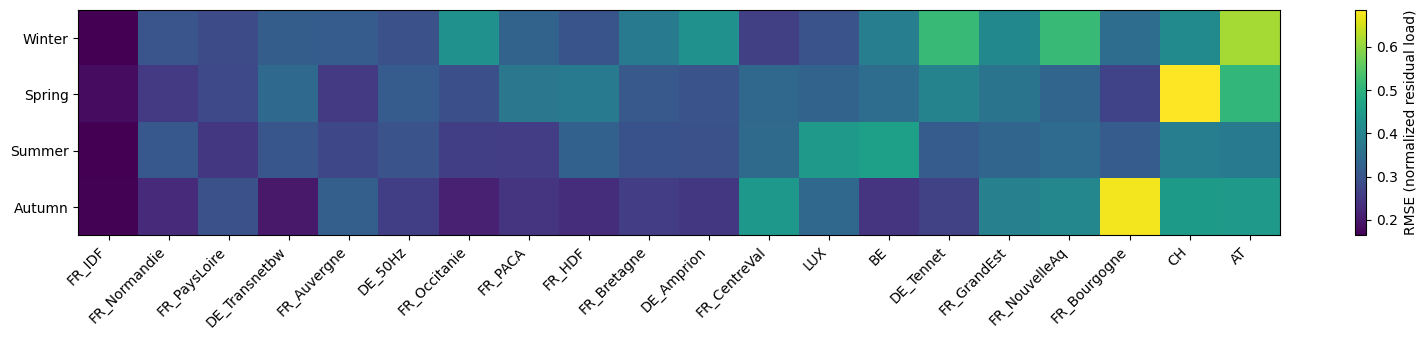

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Heatmap of RMSE (season×node)


import numpy as np
import matplotlib.pyplot as plt
from google.colab import files


season_order = ["Winter", "Spring", "Summer", "Autumn"]
df_hm = df_rmse_matrix.loc[season_order].copy()


try:
    node_order = df_rmse_node["node_id"].tolist()
    df_hm = df_hm[node_order]
except NameError:
    node_order = list(df_hm.columns)


vmin = float(df_hm.min().min())
vmax = float(df_hm.max().max())

plt.figure(figsize=(16, 3.5))
im = plt.imshow(df_hm.values, aspect="auto", vmin=vmin, vmax=vmax)

plt.yticks(range(len(df_hm.index)), df_hm.index)
plt.xticks(range(len(df_hm.columns)), df_hm.columns, rotation=45, ha="right")

cbar = plt.colorbar(im)
cbar.set_label("RMSE (normalized residual load)")

plt.grid(False)
plt.tight_layout()

PDF_PATH = "/content/rmse_heatmap_season_node.pdf"
plt.savefig(PDF_PATH, bbox_inches="tight")
plt.show()

files.download(PDF_PATH)


In [ ]:
print(y_true_scen_2d.shape, y_pred_scen_2d.shape)
print(len(scenario_times) if "scenario_times" in globals() else "no scenario_times")


(672, 20) (672, 20)
672


In [ ]:
# Subset eval on 4 held-out weeks (seasons, day/night, weekday/weekend, holiday/non-holiday)

import numpy as np
import pandas as pd


try:
    import holidays
except ImportError:
    !pip -q install holidays
    import holidays

T, N = y_true_scen_2d.shape
one_week = 7 * 24
assert T == 4 * one_week, f"Expected T=672 (4 weeks), got T={T}"


if "scenario_times" in globals() and len(scenario_times) == T:
    times = pd.to_datetime(scenario_times)
else:

    times = pd.to_datetime(df_scen_n["datetime"]).sort_values().unique()
    assert len(times) == T, f"Timestamp mismatch: got {len(times)} unique times vs T={T}"
    times = pd.to_datetime(times)


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(a, b):
    return float(np.mean(np.abs(a - b)))


MIN_HOURS = 48

def eval_subset(mask, name):
    mask = np.asarray(mask, dtype=bool)
    n_hours = int(mask.sum())
    if n_hours < MIN_HOURS:
        return {
            "Subset": name,
            "Num_hours": n_hours,
            "RMSE": np.nan,
            "MAE": np.nan,
            "Note": f"n<{MIN_HOURS}h"
        }

    yt = y_true_scen_2d[mask, :].reshape(-1)
    yp = y_pred_scen_2d[mask, :].reshape(-1)

    return {
        "Subset": name,
        "Num_hours": n_hours,
        "RMSE": rmse(yt, yp),
        "MAE": mae(yt, yp),
        "Note": ""
    }

hour = times.hour
dow  = times.dayofweek
date = times.date

mask_all = np.ones(T, dtype=bool)


mask_day   = (hour >= 7) & (hour <= 19)
mask_night = ~mask_day

mask_weekend = dow >= 5
mask_weekday = ~mask_weekend


DE_holidays = holidays.country_holidays("DE")
mask_holiday    = np.array([d in DE_holidays for d in date], dtype=bool)
mask_nonholiday = ~mask_holiday


season_names = ["Winter", "Spring", "Summer", "Autumn"]
idx = np.arange(T)
season_masks = {
    season_names[s]: (idx >= s*one_week) & (idx < (s+1)*one_week)
    for s in range(4)
}


rows = []
rows.append(eval_subset(mask_all, "Overall"))

for s in season_names:
    rows.append(eval_subset(season_masks[s], f"Season: {s}"))

rows.append(eval_subset(mask_day, "Time: Day (07–19)"))
rows.append(eval_subset(mask_night, "Time: Night"))

rows.append(eval_subset(mask_weekday, "Calendar: Weekday"))
rows.append(eval_subset(mask_weekend, "Calendar: Weekend"))

rows.append(eval_subset(mask_holiday, "Calendar: Holiday (DE)"))
rows.append(eval_subset(mask_nonholiday, "Calendar: Non-holiday (DE)"))

df_metrics = pd.DataFrame(rows)


def fmt(x):
    return "n/a" if pd.isna(x) else f"{x:.4f}"

df_out = df_metrics.copy()
df_out["RMSE"] = df_out["RMSE"].map(fmt)
df_out["MAE"]  = df_out["MAE"].map(fmt)

print(df_out.to_string(index=False))
OUT_CSV = "/content/subset_metrics_4weeks.csv"
df_metrics.to_csv(OUT_CSV, index=False)
print("\nSaved raw metrics to:", OUT_CSV)


                    Subset  Num_hours   RMSE    MAE  Note
                   Overall        672 0.3503 0.2639      
            Season: Winter        168 0.3789 0.2909      
            Season: Spring        168 0.3577 0.2684      
            Season: Summer        168 0.3246 0.2465      
            Season: Autumn        168 0.3376 0.2499      
         Time: Day (07–19)        364 0.3834 0.2936      
               Time: Night        308 0.3067 0.2289      
         Calendar: Weekday        480 0.3448 0.2605      
         Calendar: Weekend        192 0.3637 0.2726      
    Calendar: Holiday (DE)          0    n/a    n/a n<48h
Calendar: Non-holiday (DE)        672 0.3503 0.2639      

Saved raw metrics to: /content/subset_metrics_4weeks.csv


In [ ]:
#LaTeX table of subset metrics

import pandas as pd
import numpy as np

df_tab = df_metrics.copy()

def fmt_num(x, digits=4):
    if pd.isna(x):
        return "n/a"
    return f"{float(x):.{digits}f}"

df_tab["RMSE"] = df_tab["RMSE"].apply(fmt_num)
df_tab["MAE"]  = df_tab["MAE"].apply(fmt_num)

# df_tab["Subset"] = df_tab["Subset"].str.replace("Calendar: ", "", regex=False)

lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{l r r r}")
lines.append(r"\toprule")
lines.append(r"Subset & $n$ (hours) & RMSE & MAE \\")
lines.append(r"\midrule")

for _, row in df_tab.iterrows():
    subset = str(row["Subset"]).replace("&", r"\&")
    n_hours = int(row["Num_hours"])
    rmse = row["RMSE"]
    mae  = row["MAE"]
    lines.append(rf"{subset} & {n_hours} & {rmse} & {mae} \\")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Subset evaluation on the four held-out seasonal test weeks. Metrics are computed on normalized residual load. Entries marked as n/a indicate insufficient samples in the subset.}")
lines.append(r"\label{tab:subset_metrics}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

out_path = "/content/subset_metrics_table.tex"
with open(out_path, "w") as f:
    f.write(latex_table)

print("\nSaved to:", out_path)


\begin{table}[t]
\centering
\begin{tabular}{l r r r}
\toprule
Subset & $n$ (hours) & RMSE & MAE \\
\midrule
Overall & 672 & 0.3503 & 0.2639 \\
Season: Winter & 168 & 0.3789 & 0.2909 \\
Season: Spring & 168 & 0.3577 & 0.2684 \\
Season: Summer & 168 & 0.3246 & 0.2465 \\
Season: Autumn & 168 & 0.3376 & 0.2499 \\
Time: Day (07–19) & 364 & 0.3834 & 0.2936 \\
Time: Night & 308 & 0.3067 & 0.2289 \\
Calendar: Weekday & 480 & 0.3448 & 0.2605 \\
Calendar: Weekend & 192 & 0.3637 & 0.2726 \\
Calendar: Holiday (DE) & 0 & n/a & n/a \\
Calendar: Non-holiday (DE) & 672 & 0.3503 & 0.2639 \\
\bottomrule
\end{tabular}
\caption{Subset evaluation on the four held-out seasonal test weeks. Metrics are computed on normalized residual load. Entries marked as n/a indicate insufficient samples in the subset.}
\label{tab:subset_metrics}
\end{table}

Saved to: /content/subset_metrics_table.tex


 Hour  Num_hours   RMSE    MAE
    0         28 0.2968 0.2246
    1         28 0.3120 0.2321
    2         28 0.3024 0.2206
    3         28 0.3083 0.2293
    4         28 0.3174 0.2359
    5         28 0.3076 0.2280
    6         28 0.3181 0.2332
    7         28 0.3269 0.2431
    8         28 0.3485 0.2689
    9         28 0.3733 0.2860
   10         28 0.3910 0.3024
   11         28 0.4217 0.3294
   12         28 0.4354 0.3404
   13         28 0.4364 0.3392
   14         28 0.4111 0.3177
   15         28 0.3910 0.3025
   16         28 0.3786 0.2928
   17         28 0.3691 0.2794
   18         28 0.3485 0.2592
   19         28 0.3305 0.2563
   20         28 0.3123 0.2365
   21         28 0.3021 0.2249
   22         28 0.3002 0.2316
   23         28 0.2951 0.2207

Saved CSV to: /content/hour_of_day_metrics.csv


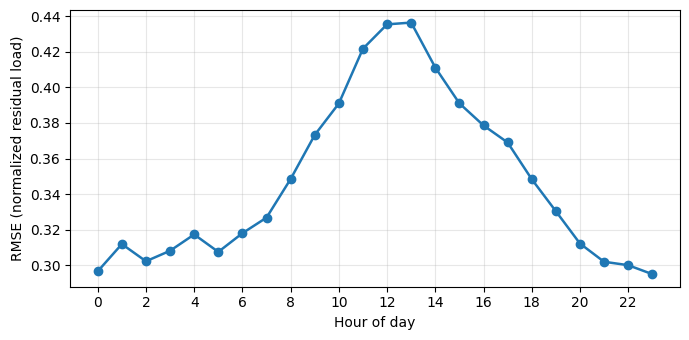

Saved plot to: /content/rmse_by_hour_of_day.pdf

LaTeX table:

\begin{table}[t]
\centering
\begin{tabular}{r r r r}
\toprule
Hour & $n$ (hours) & RMSE & MAE \\
\midrule
0 & 28 & 0.2968 & 0.2246 \\
1 & 28 & 0.3120 & 0.2321 \\
2 & 28 & 0.3024 & 0.2206 \\
3 & 28 & 0.3083 & 0.2293 \\
4 & 28 & 0.3174 & 0.2359 \\
5 & 28 & 0.3076 & 0.2280 \\
6 & 28 & 0.3181 & 0.2332 \\
7 & 28 & 0.3269 & 0.2431 \\
8 & 28 & 0.3485 & 0.2689 \\
9 & 28 & 0.3733 & 0.2860 \\
10 & 28 & 0.3910 & 0.3024 \\
11 & 28 & 0.4217 & 0.3294 \\
12 & 28 & 0.4354 & 0.3404 \\
13 & 28 & 0.4364 & 0.3392 \\
14 & 28 & 0.4111 & 0.3177 \\
15 & 28 & 0.3910 & 0.3025 \\
16 & 28 & 0.3786 & 0.2928 \\
17 & 28 & 0.3691 & 0.2794 \\
18 & 28 & 0.3485 & 0.2592 \\
19 & 28 & 0.3305 & 0.2563 \\
20 & 28 & 0.3123 & 0.2365 \\
21 & 28 & 0.3021 & 0.2249 \\
22 & 28 & 0.3002 & 0.2316 \\
23 & 28 & 0.2951 & 0.2207 \\
\bottomrule
\end{tabular}
\caption{Hour-of-day evaluation on the four held-out seasonal test weeks. Metrics are averaged over all nodes and days 

In [ ]:
#hour-of-day evaluation (4 weeks)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


T, N = y_true_scen_2d.shape
one_week = 7 * 24
assert T == 4 * one_week, f"Expected T=672 (4 weeks hourly), got T={T}"


if "scenario_times" in globals() and len(scenario_times) == T:
    times = scenario_times
else:
    # fallback: derive from df_scen_n; assumes complete panel (all nodes each hour)
    times = pd.to_datetime(df_scen_n["datetime"]).sort_values().unique()
    assert len(times) == T, f"Timestamp mismatch: got {len(times)} unique times vs T={T}"

times = pd.to_datetime(times)
hours = times.hour


def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def mae(a, b):
    return float(np.mean(np.abs(a - b)))

rows = []
for h in range(24):
    mask = (hours == h)
    n_hours = int(np.sum(mask))

    yt = y_true_scen_2d[mask, :].reshape(-1)
    yp = y_pred_scen_2d[mask, :].reshape(-1)

    rows.append({
        "Hour": h,
        "Num_hours": n_hours,
        "RMSE": rmse(yt, yp),
        "MAE": mae(yt, yp),
    })

df_hour = pd.DataFrame(rows)

print(df_hour.round(4).to_string(index=False))


CSV_PATH = "/content/hour_of_day_metrics.csv"
df_hour.to_csv(CSV_PATH, index=False)
print("\nSaved CSV to:", CSV_PATH)

plt.figure(figsize=(7, 3.5))
plt.plot(df_hour["Hour"], df_hour["RMSE"], marker="o", linewidth=1.8)

plt.xlabel("Hour of day")
plt.ylabel("RMSE (normalized residual load)")
plt.xticks(range(0, 24, 2))
plt.grid(True, alpha=0.3)
plt.tight_layout()

PDF_PATH = "/content/rmse_by_hour_of_day.pdf"
plt.savefig(PDF_PATH, bbox_inches="tight")
plt.show()

print("Saved plot to:", PDF_PATH)


lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{r r r r}")
lines.append(r"\toprule")
lines.append(r"Hour & $n$ (hours) & RMSE & MAE \\")
lines.append(r"\midrule")

for _, r in df_hour.iterrows():
    lines.append(
        rf"{int(r['Hour'])} & {int(r['Num_hours'])} & {float(r['RMSE']):.4f} & {float(r['MAE']):.4f} \\"
    )

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Hour-of-day evaluation on the four held-out seasonal test weeks. Metrics are averaged over all nodes and days for each hour.}")
lines.append(r"\label{tab:hour_of_day_metrics}")
lines.append(r"\end{table}")

latex_hour_table = "\n".join(lines)
print("\nLaTeX table:\n")
print(latex_hour_table)

LATEX_PATH = "/content/hour_of_day_metrics.tex"
with open(LATEX_PATH, "w") as f:
    f.write(latex_hour_table)

print("\nSaved LaTeX table to:", LATEX_PATH)


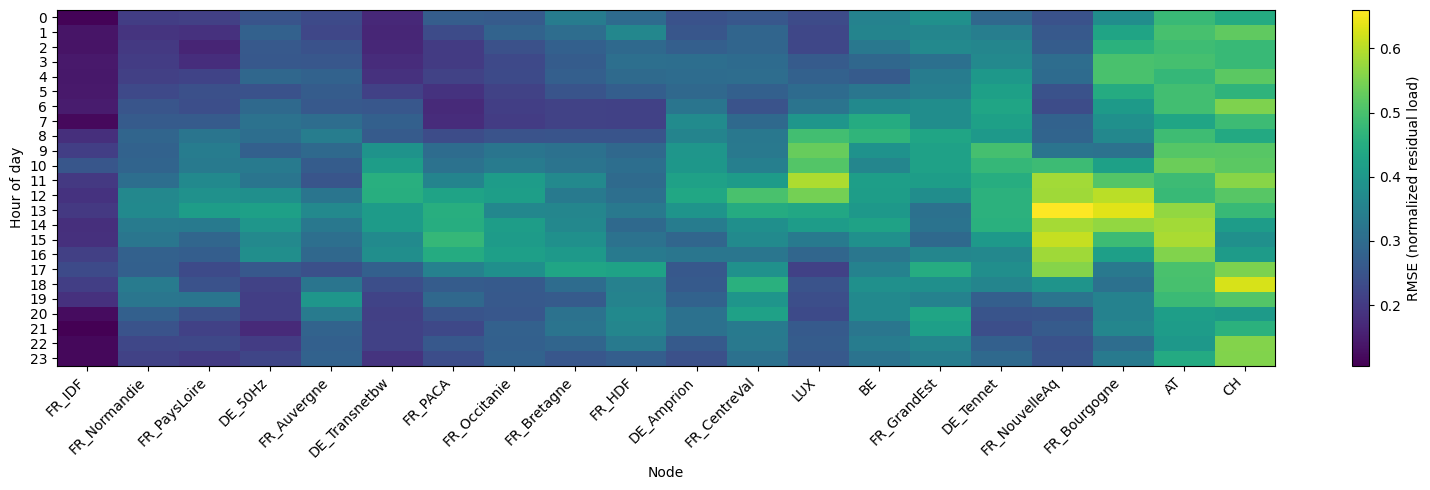

Saved to: /content/rmse_heatmap_hour_node.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#heatmap of RMSE (hour-of-day × node)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files


T, N = y_true_scen_2d.shape
one_week = 7 * 24
assert T == 4 * one_week, f"Expected T=672, got T={T}"


if "scenario_times" in globals() and len(scenario_times) == T:
    times = scenario_times
else:
    times = pd.to_datetime(df_scen_n["datetime"]).sort_values().unique()
    assert len(times) == T, "Timestamp mismatch"


times = pd.to_datetime(times)
hours = times.hour
if not isinstance(hours, np.ndarray):
    hours = hours.to_numpy()


if "node_index_map" in globals():
    node_ids_by_index = [None] * len(node_index_map)
    for nid, idx in node_index_map.items():
        node_ids_by_index[idx] = nid
else:
    node_ids_by_index = list(node_ids)


rmse_hour_node = np.zeros((24, N), dtype=float)

for h in range(24):
    mask = (hours == h)
    err = y_true_scen_2d[mask, :] - y_pred_scen_2d[mask, :]
    rmse_hour_node[h, :] = np.sqrt(np.mean(err ** 2, axis=0))

df_hm = pd.DataFrame(
    rmse_hour_node,
    index=[str(h) for h in range(24)],
    columns=node_ids_by_index,
)


rmse_per_node = np.sqrt(np.mean((y_true_scen_2d - y_pred_scen_2d) ** 2, axis=0))
node_order = [node_ids_by_index[i] for i in np.argsort(rmse_per_node)]
df_hm = df_hm[node_order]


vmin = float(df_hm.min().min())
vmax = float(df_hm.max().max())

plt.figure(figsize=(16, 5))
im = plt.imshow(df_hm.values, aspect="auto", vmin=vmin, vmax=vmax)

plt.yticks(range(24), df_hm.index)
plt.xticks(range(len(df_hm.columns)), df_hm.columns, rotation=45, ha="right")

cbar = plt.colorbar(im)
cbar.set_label("RMSE (normalized residual load)")

plt.xlabel("Node")
plt.ylabel("Hour of day")
plt.tight_layout()

PDF_PATH = "/content/rmse_heatmap_hour_node.pdf"
plt.savefig(PDF_PATH, bbox_inches="tight")
plt.show()

print("Saved to:", PDF_PATH)
files.download(PDF_PATH)


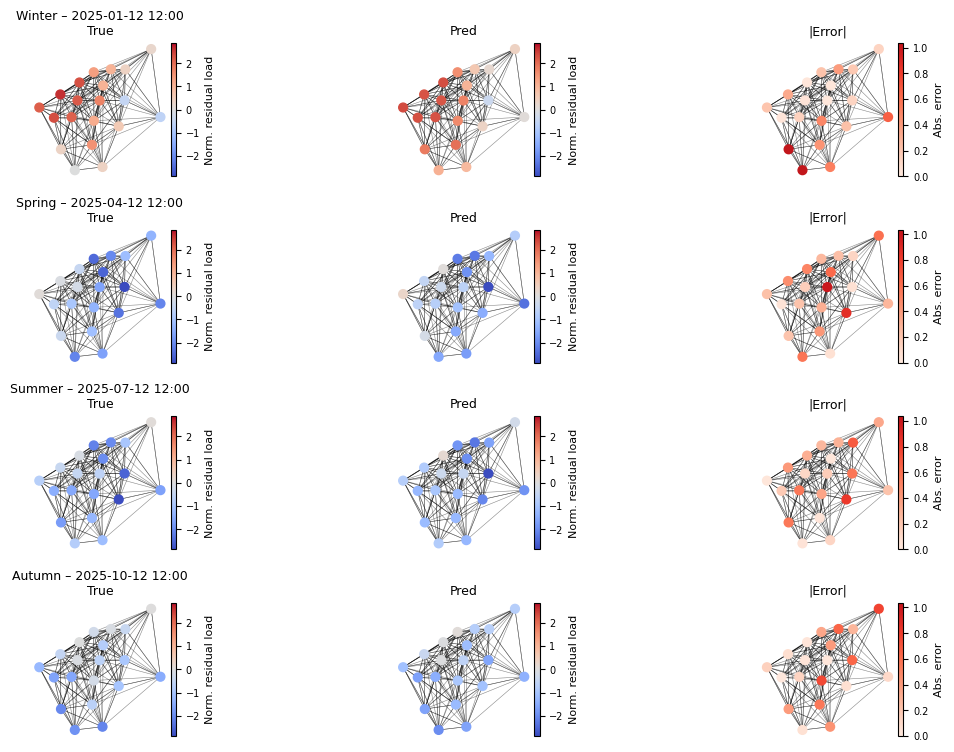

Selected timesteps (season, t, datetime):
  Winter: t= 60, 2025-01-12 12:00:00
  Spring: t=228, 2025-04-12 12:00:00
  Summer: t=396, 2025-07-12 12:00:00
  Autumn: t=564, 2025-10-12 12:00:00
Saved figure to: /content/operator_graph_snapshots_seasons_4x3_panel_colorbars.pdf


In [11]:
#4×3 seasonal graph snapshots

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap


T, N = y_true_scen_2d.shape
one_week = 7 * 24
assert T == 4 * one_week, f"Expected T=672, got {T}"


if "scenario_times" in globals() and len(scenario_times) == T:
    times = pd.to_datetime(scenario_times)
else:
    times = pd.to_datetime(df_scen_n["datetime"]).sort_values().unique()
    assert len(times) == T
times = pd.to_datetime(times)


abs_max = np.percentile(
    np.abs(np.concatenate([y_true_scen_2d.ravel(), y_pred_scen_2d.ravel()])),
    98
)
vmin_load, vmax_load = -abs_max, abs_max

err_ref = np.percentile(np.abs(y_true_scen_2d - y_pred_scen_2d), 99)

cmap_load = plt.get_cmap("coolwarm")

base = plt.get_cmap("Reds")
cmap_error = LinearSegmentedColormap.from_list(
    "Reds_soft",
    base(np.linspace(0.08, 0.78, 256))
)

def _draw_edges(ax):
    pos_np = pos.cpu().numpy()
    lat = pos_np[:, 0]
    lon = pos_np[:, 1]
    r, c = edge_index
    for i, j in zip(r.tolist(), c.tolist()):
        ax.plot([lon[i], lon[j]], [lat[i], lat[j]],
                color="k", lw=0.4, alpha=0.25)

def plot_graph(ax, values, title, cmap, vmin, vmax, cbar_label=None):
    pos_np = pos.cpu().numpy()
    lat = pos_np[:, 0]
    lon = pos_np[:, 1]

    _draw_edges(ax)

    sc = ax.scatter(
        lon, lat,
        c=values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=40,
        zorder=3
    )
    ax.set_title(title, fontsize=9)
    ax.axis("equal")
    ax.axis("off")

    # Per-panel colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.04)
    cb = plt.colorbar(sc, cax=cax)
    if cbar_label is not None:
        cb.set_label(cbar_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)

    return sc

season_names = ["Winter", "Spring", "Summer", "Autumn"]

fixed_offset = 2 * 24 + 12
ramp_quantile = 0.95
selected = []
for s, season in enumerate(season_names):
    start, end = s * one_week, (s + 1) * one_week

    dy = np.diff(y_true_scen_2d[start:end, :], axis=0)
    ramp_strength = np.mean(np.abs(dy), axis=1)
    thr = np.quantile(ramp_strength, ramp_quantile)

    non_ramp_local = np.where(ramp_strength <= thr)[0]
    candidates = start + non_ramp_local + 1

    t_target = np.clip(start + fixed_offset, start + 1, end - 1)
    t = int(candidates[np.argmin(np.abs(candidates - t_target))])

    selected.append((season, t, times[t]))


fig, axes = plt.subplots(4, 3, figsize=(13, 9))
plt.subplots_adjust(hspace=0.40, wspace=0.30)

for row, (season, t, dt) in enumerate(selected):
    y_true = y_true_scen_2d[t]
    y_pred = y_pred_scen_2d[t]
    y_err  = np.abs(y_true - y_pred)

    plot_graph(
        axes[row, 0], y_true,
        f"{season} – {dt:%Y-%m-%d %H:%M}\nTrue",
        cmap=cmap_load, vmin=vmin_load, vmax=vmax_load,
        cbar_label="Norm. residual load"
    )
    plot_graph(
        axes[row, 1], y_pred,
        "Pred",
        cmap=cmap_load, vmin=vmin_load, vmax=vmax_load,
        cbar_label="Norm. residual load"
    )
    plot_graph(
        axes[row, 2], y_err,
        "|Error|",
        cmap=cmap_error, vmin=0.0, vmax=err_ref,
        cbar_label="Abs. error"
    )


PDF_PATH = "/content/operator_graph_snapshots_seasons_4x3_panel_colorbars.pdf"
plt.savefig(PDF_PATH, bbox_inches="tight")
plt.show()

print("Selected timesteps (season, t, datetime):")
for s, t, dt in selected:
    print(f"  {s:>6}: t={t:>3d}, {dt}")
print("Saved figure to:", PDF_PATH)


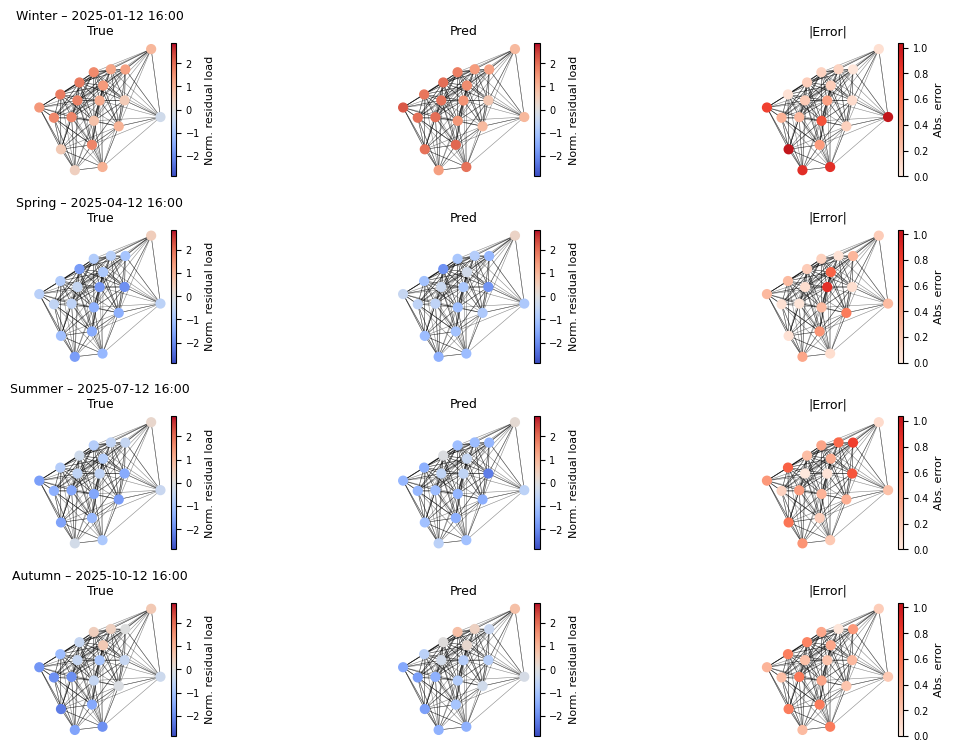

Selected timesteps (season, t, datetime):
  Winter: t= 64, 2025-01-12 16:00:00
  Spring: t=232, 2025-04-12 16:00:00
  Summer: t=400, 2025-07-12 16:00:00
  Autumn: t=568, 2025-10-12 16:00:00
Saved figure to: /content/operator_graph_snapshots_seasons_4x3_panel_colorbars.pdf


In [13]:
#4×3 seasonal graph snapshots

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap


T, N = y_true_scen_2d.shape
one_week = 7 * 24
assert T == 4 * one_week, f"Expected T=672, got {T}"


if "scenario_times" in globals() and len(scenario_times) == T:
    times = pd.to_datetime(scenario_times)
else:
    times = pd.to_datetime(df_scen_n["datetime"]).sort_values().unique()
    assert len(times) == T
times = pd.to_datetime(times)


abs_max = np.percentile(
    np.abs(np.concatenate([y_true_scen_2d.ravel(), y_pred_scen_2d.ravel()])),
    98
)
vmin_load, vmax_load = -abs_max, abs_max

err_ref = np.percentile(np.abs(y_true_scen_2d - y_pred_scen_2d), 99)


cmap_load = plt.get_cmap("coolwarm")


base = plt.get_cmap("Reds")
cmap_error = LinearSegmentedColormap.from_list(
    "Reds_soft",
    base(np.linspace(0.08, 0.78, 256))
)


def _draw_edges(ax, pos, edge_index):
    pos_np = pos.cpu().numpy()
    lat = pos_np[:, 0]
    lon = pos_np[:, 1]
    r, c = edge_index
    for i, j in zip(r.tolist(), c.tolist()):
        ax.plot([lon[i], lon[j]], [lat[i], lat[j]],
                color="k", lw=0.4, alpha=0.25)

def plot_graph(ax, values, title, cmap, vmin, vmax, pos, edge_index, cbar_label=None):
    pos_np = pos.cpu().numpy()
    lat = pos_np[:, 0]
    lon = pos_np[:, 1]

    _draw_edges(ax, pos, edge_index)

    sc = ax.scatter(
        lon, lat,
        c=values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        s=40,
        zorder=3
    )
    ax.set_title(title, fontsize=9)
    ax.axis("equal")
    ax.axis("off")


    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.04)
    cb = plt.colorbar(sc, cax=cax)
    if cbar_label is not None:
        cb.set_label(cbar_label, fontsize=8)
    cb.ax.tick_params(labelsize=7)

    return sc


season_names = ["Winter", "Spring", "Summer", "Autumn"]


fixed_offset = 2 * 24 + 16

selected = []
for s, season in enumerate(season_names):
    start = s * one_week


    t = start + fixed_offset

    selected.append((season, t, times[t]))


fig, axes = plt.subplots(4, 3, figsize=(13, 9))
plt.subplots_adjust(hspace=0.40, wspace=0.30)

for row, (season, t, dt) in enumerate(selected):
    y_true = y_true_scen_2d[t]
    y_pred = y_pred_scen_2d[t]
    y_err  = np.abs(y_true - y_pred)


    plot_graph(
        axes[row, 0], y_true,
        f"{season} – {dt:%Y-%m-%d %H:%M}\nTrue",
        cmap=cmap_load, vmin=vmin_load, vmax=vmax_load,
        pos=pos, edge_index=edge_index,
        cbar_label="Norm. residual load"
    )

    plot_graph(
        axes[row, 1], y_pred,
        "Pred",
        cmap=cmap_load, vmin=vmin_load, vmax=vmax_load,
        pos=pos, edge_index=edge_index,
        cbar_label="Norm. residual load"
    )

    plot_graph(
        axes[row, 2], y_err,
        "|Error|",
        cmap=cmap_error, vmin=0.0, vmax=err_ref,
        pos=pos, edge_index=edge_index,
        cbar_label="Abs. error"
    )

PDF_PATH = "/content/operator_graph_snapshots_seasons_4x3_panel_colorbars.pdf"
plt.savefig(PDF_PATH, bbox_inches="tight")
plt.show()

print("Selected timesteps (season, t, datetime):")
for s, t, dt in selected:
    print(f"  {s:>6}: t={t:>3d}, {dt}")
print("Saved figure to:", PDF_PATH)

In [ ]:
#Curve dynamics metrics (4 weeks, ramps + correlation)


import numpy as np
import pandas as pd


T, N = y_true_scen_2d.shape
one_week = 7 * 24
assert T == 4 * one_week, f"Expected T=672, got {T}"

yt = y_true_scen_2d
yp = y_pred_scen_2d


def _rmse(x):
    return float(np.sqrt(np.mean(x**2)))

def _mae(x):
    return float(np.mean(np.abs(x)))

def pearson_corr(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    a0 = a - a.mean()
    b0 = b - b.mean()
    denom = (np.sqrt(np.sum(a0**2)) * np.sqrt(np.sum(b0**2)))
    if denom == 0:
        return np.nan
    return float(np.sum(a0 * b0) / denom)


corr_nodes = np.array([pearson_corr(yt[:, j], yp[:, j]) for j in range(N)])
corr_graph = pearson_corr(yt.reshape(-1), yp.reshape(-1))



dyt = np.diff(yt, axis=0)
dyp = np.diff(yp, axis=0)
derr = dyt - dyp


ramp_mae_graph  = _mae(derr.reshape(-1))
ramp_rmse_graph = _rmse(derr.reshape(-1))


ramp_mae_nodes  = np.mean(np.abs(derr), axis=0)
ramp_rmse_nodes = np.sqrt(np.mean(derr**2, axis=0))




thr = float(np.quantile(np.abs(dyt).reshape(-1), 0.20))

mask = (np.abs(dyt) >= thr)
sign_match = (np.sign(dyt) == np.sign(dyp)) & mask


num = np.sum(sign_match)
den = np.sum(mask)
ramp_dir_acc_graph = float(num / den) if den > 0 else np.nan


ramp_dir_acc_nodes = np.zeros(N, dtype=float)
for j in range(N):
    mj = mask[:, j]
    denj = np.sum(mj)
    if denj == 0:
        ramp_dir_acc_nodes[j] = np.nan
    else:
        ramp_dir_acc_nodes[j] = float(
            np.mean((np.sign(dyt[mj, j]) == np.sign(dyp[mj, j])).astype(float))
        )


df_summary = pd.DataFrame([{
    "Metric": "Correlation (levels, graph-wide)",
    "Value": corr_graph
},{
    "Metric": "Ramp MAE (Δy, graph-wide)",
    "Value": ramp_mae_graph
},{
    "Metric": "Ramp RMSE (Δy, graph-wide)",
    "Value": ramp_rmse_graph
},{
    "Metric": f"Ramp direction accuracy (|Δy| >= q20={thr:.4f})",
    "Value": ramp_dir_acc_graph
}])

df_node_metrics = pd.DataFrame({
    "node_idx": np.arange(N),
    "Correlation_levels": corr_nodes,
    "Ramp_MAE": ramp_mae_nodes,
    "Ramp_RMSE": ramp_rmse_nodes,
    "Ramp_dir_acc": ramp_dir_acc_nodes,
})


if "node_ids" in globals() and len(node_ids) == N:
    df_node_metrics.insert(0, "node_id", node_ids)

print("=== Graph-wide curve/dynamics metrics (held-out weeks) ===")
print(df_summary.round(4).to_string(index=False))

print("\n=== Per-node metrics (first 10 rows) ===")
print(df_node_metrics.head(10).round(4).to_string(index=False))


lines = []
lines.append(r"\begin{table}[t]")
lines.append(r"\centering")
lines.append(r"\begin{tabular}{l r}")
lines.append(r"\toprule")
lines.append(r"Metric & Value \\")
lines.append(r"\midrule")
for _, row in df_summary.iterrows():
    lines.append(rf"{row['Metric']} & {float(row['Value']):.4f} \\")
lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"\caption{Curve- and dynamics-based evaluation on the four held-out seasonal test weeks. Ramp metrics are computed on first differences $\Delta y_t = y_t - y_{t-1}$. Ramp direction accuracy is computed on non-trivial ramps only (smallest 20\% of $|\Delta y|$ are ignored).}")
lines.append(r"\label{tab:curve_dynamics_metrics}")
lines.append(r"\end{table}")
latex_summary = "\n".join(lines)

print("\nLaTeX summary table:\n")
print(latex_summary)


=== Graph-wide curve/dynamics metrics (held-out weeks) ===
                                      Metric  Value
            Correlation (levels, graph-wide) 0.9564
                   Ramp MAE (Δy, graph-wide) 0.1419
                  Ramp RMSE (Δy, graph-wide) 0.1994
Ramp direction accuracy (|Δy| >= q20=0.0558) 0.8229

=== Per-node metrics (first 10 rows) ===
      node_id  node_idx  Correlation_levels  Ramp_MAE  Ramp_RMSE  Ramp_dir_acc
           AT         0              0.9069    0.1532     0.2038        0.7893
           BE         1              0.9458    0.1388     0.1893        0.8430
           CH         2              0.9096    0.3065     0.4226        0.6819
      DE_50Hz         3              0.9523    0.1371     0.1851        0.8168
   DE_Amprion         4              0.9569    0.1222     0.1594        0.8340
    DE_Tennet         5              0.8969    0.1292     0.1747        0.8129
DE_Transnetbw         6              0.9520    0.1238     0.1656        0.8971
  FR_Au

In [ ]:
#Latex table for curve dynamics

import pandas as pd


cols = ["node_id", "Correlation_levels", "Ramp_MAE", "Ramp_RMSE", "Ramp_dir_acc"]
df_tab = df_node_metrics[cols].copy()


df_tab = df_tab.sort_values("Ramp_RMSE", ascending=True)


df_tab = df_tab.rename(columns={
    "node_id": "Node",
    "Correlation_levels": r"$\rho(y,\hat y)$",
    "Ramp_MAE": r"MAE($\Delta y$)",
    "Ramp_RMSE": r"RMSE($\Delta y$)",
    "Ramp_dir_acc": r"DirAcc($\Delta y$)"
})


for c in df_tab.columns[1:]:
    df_tab[c] = df_tab[c].map(lambda x: f"{x:.4f}")

latex = df_tab.to_latex(
    index=False,
    escape=False,
    longtable=True,
    column_format="lrrrr",
    caption=(
        "Per-node curve- and dynamics-based evaluation on the four held-out seasonal test weeks. "
        r"$\rho(y,\hat y)$ denotes Pearson correlation on levels; ramp metrics are computed on first differences "
        r"$\Delta y_t = y_t - y_{t-1}$; DirAcc denotes ramp direction accuracy on non-trivial ramps."
    ),
    label="tab:node_curve_dynamics"
)


latex = latex.replace(r"\toprule", r"\toprule")
latex = latex.replace(r"\midrule", r"\midrule")
latex = latex.replace(r"\bottomrule", r"\bottomrule")

latex = latex.replace(
    r"\begin{longtable}",
    r"\small" "\n"
    r"\setlength{\tabcolsep}{4pt}" "\n"
    r"\renewcommand{\arraystretch}{1.1}" "\n"
    r"\begin{longtable}"
)
latex = latex.replace(r"\end{longtable}", r"\end{longtable}" "\n" r"\normalsize")

print(latex)

out_path = "/content/node_curve_dynamics_table.tex"
with open(out_path, "w") as f:
    f.write(latex)

print("Saved to:", out_path)


\small
\setlength{\tabcolsep}{4pt}
\renewcommand{\arraystretch}{1.1}
\begin{longtable}{lrrrr}
\caption{Per-node curve- and dynamics-based evaluation on the four held-out seasonal test weeks. $\rho(y,\hat y)$ denotes Pearson correlation on levels; ramp metrics are computed on first differences $\Delta y_t = y_t - y_{t-1}$; DirAcc denotes ramp direction accuracy on non-trivial ramps.} \label{tab:node_curve_dynamics} \\
\toprule
Node & $\rho(y,\hat y)$ & MAE($\Delta y$) & RMSE($\Delta y$) & DirAcc($\Delta y$) \\
\midrule
\endfirsthead
\caption[]{Per-node curve- and dynamics-based evaluation on the four held-out seasonal test weeks. $\rho(y,\hat y)$ denotes Pearson correlation on levels; ramp metrics are computed on first differences $\Delta y_t = y_t - y_{t-1}$; DirAcc denotes ramp direction accuracy on non-trivial ramps.} \\
\toprule
Node & $\rho(y,\hat y)$ & MAE($\Delta y$) & RMSE($\Delta y$) & DirAcc($\Delta y$) \\
\midrule
\endhead
\midrule
\multicolumn{5}{r}{Continued on next page} \

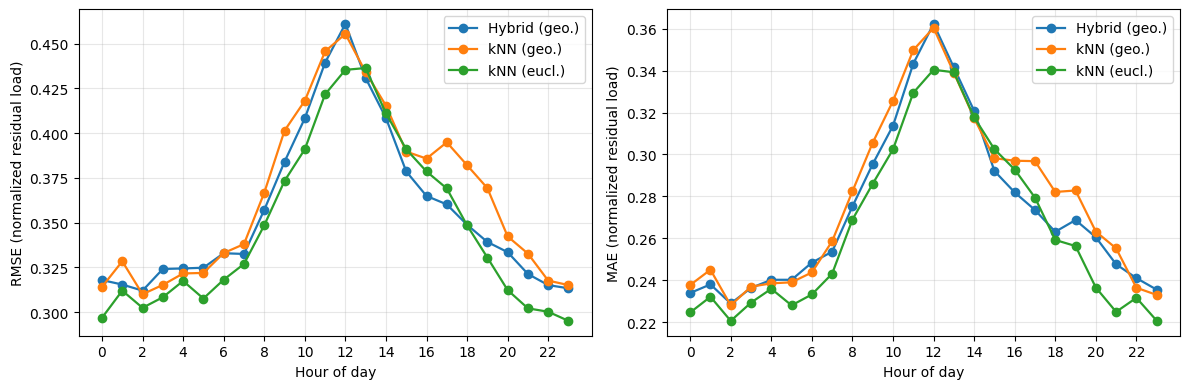

Saved plot to: /content/hourly_rmse_mae_models_hybrid_knn_geo_eucl.pdf


In [2]:
#plot hourly metrics
import pandas as pd
import matplotlib.pyplot as plt


hours = list(range(24))

# Model A: Hybrid
rmse_A = [0.3179, 0.3154, 0.3120, 0.3241, 0.3244, 0.3248, 0.3329, 0.3325,
          0.3571, 0.3840, 0.4083, 0.4394, 0.4611, 0.4308, 0.4085, 0.3786,
          0.3649, 0.3602, 0.3488, 0.3392, 0.3335, 0.3213, 0.3151, 0.3133]
mae_A  = [0.2339, 0.2380, 0.2289, 0.2363, 0.2402, 0.2402, 0.2484, 0.2536,
          0.2752, 0.2954, 0.3137, 0.3433, 0.3623, 0.3415, 0.3208, 0.2921,
          0.2819, 0.2735, 0.2631, 0.2687, 0.2605, 0.2476, 0.2410, 0.2355]

rmse_B = [0.3141, 0.3284, 0.3100, 0.3152, 0.3216, 0.3219, 0.3330, 0.3380,
          0.3667, 0.4014, 0.4181, 0.4457, 0.4555, 0.4341, 0.4154, 0.3897,
          0.3858, 0.3949, 0.3821, 0.3693, 0.3423, 0.3327, 0.3176, 0.3151]
mae_B  = [0.2377, 0.2450, 0.2280, 0.2369, 0.2385, 0.2390, 0.2437, 0.2586,
          0.2824, 0.3056, 0.3255, 0.3498, 0.3604, 0.3390, 0.3173, 0.2982,
          0.2970, 0.2968, 0.2821, 0.2828, 0.2632, 0.2552, 0.2364, 0.2330]


rmse_C = [0.2968, 0.3120, 0.3024, 0.3083, 0.3174, 0.3076, 0.3181, 0.3269,
          0.3485, 0.3733, 0.3910, 0.4217, 0.4354, 0.4364, 0.4111, 0.3910,
          0.3786, 0.3691, 0.3485, 0.3305, 0.3123, 0.3021, 0.3002, 0.2951]
mae_C  = [0.2246, 0.2321, 0.2206, 0.2293, 0.2359, 0.2280, 0.2332, 0.2431,
          0.2689, 0.2860, 0.3024, 0.3294, 0.3404, 0.3392, 0.3177, 0.3025,
          0.2928, 0.2794, 0.2592, 0.2563, 0.2365, 0.2249, 0.2316, 0.2207]


df_hour = pd.DataFrame({
    "Hour": hours,
    "RMSE_A": rmse_A, "MAE_A": mae_A,
    "RMSE_B": rmse_B, "MAE_B": mae_B,
    "RMSE_C": rmse_C, "MAE_C": mae_C,
})


fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)


axes[0].plot(df_hour["Hour"], df_hour["RMSE_A"], marker="o", linewidth=1.6, label="Hybrid (geo.)")
axes[0].plot(df_hour["Hour"], df_hour["RMSE_B"], marker="o", linewidth=1.6, label="kNN (geo.)")
axes[0].plot(df_hour["Hour"], df_hour["RMSE_C"], marker="o", linewidth=1.6, label="kNN (eucl.)")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("RMSE (normalized residual load)")
axes[0].set_xticks(range(0, 24, 2))
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_hour["Hour"], df_hour["MAE_A"], marker="o", linewidth=1.6, label="Hybrid (geo.)")
axes[1].plot(df_hour["Hour"], df_hour["MAE_B"], marker="o", linewidth=1.6, label="kNN (geo.)")
axes[1].plot(df_hour["Hour"], df_hour["MAE_C"], marker="o", linewidth=1.6, label="kNN (eucl.)")
axes[1].set_xlabel("Hour of day")
axes[1].set_ylabel("MAE (normalized residual load)")
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()

PDF_PATH = "/content/hourly_rmse_mae_models_hybrid_knn_geo_eucl.pdf"
plt.savefig(PDF_PATH, bbox_inches="tight")
plt.show()

print("Saved plot to:", PDF_PATH)

